# Machine Learning for Space Exploration: Pulsar Star Classification (Edge AI)

## Abstract and Project Objectives
Radio telescope observations of the universe generate massive amounts of data (Big Data). The vast majority of the captured signals are simply cosmic noise (Radio Frequency Interference - RFI), while only a tiny fraction represents genuine emissions from **Pulsar Stars**. 
The goal of this project is to design, train, and evaluate a Machine Learning model capable of autonomously distinguishing noise from pulsars, explicitly optimized for an **Edge AI** application. The model must be lightweight and interpretable enough to be translated into low-level C/C++ code and deployed directly onto a satellite's microcontroller. This allows the raw data to be filtered directly in orbit, saving precious transmission bandwidth back to Earth.

## Task, Model, Approach
* **The Task:** Supervised Binary Classification (Class 0: Noise | Class 1: Pulsar).
* **The Dataset:** HTRU_2, containing physical and statistical measurements of the integrated radio profile and the dispersion curve of the signals (highly imbalanced dataset, ~90% noise).
* **The Model:** A **Decision Tree** trained using Information Theory (Shannon Entropy and Information Gain). This model was chosen over Neural Networks or complex Ensemble algorithms because it offers the optimal trade-off between predictive power, extremely low computational cost, and total logical interpretability (White-Box model).
* **Evaluation Strategy:** Due to the severe class imbalance, global Accuracy is a misleading and flawed metric. Model optimization and the final Benchmark will focus strictly on maximizing **Recall** for the Pulsar class. This minimizes False Negatives, ensuring we do not accidentally discard a genuine scientific discovery.

## Setup

In [38]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score

## 1. Exploratory Data Analysis (EDA)

   Mean_Profile  STD_Profile  Kurtosis_Profile  Skewness_Profile  Mean_Curve  STD_Curve  Kurtosis_Curve  Skewness_Curve  Target_Class
0    140.562500    55.683782         -0.234571         -0.699648    3.199833  19.110426        7.975532       74.242225             0
1    102.507812    58.882430          0.465318         -0.515088    1.677258  14.860146       10.576487      127.393580             0
2    103.015625    39.341649          0.323328          1.051164    3.121237  21.744669        7.735822       63.171909             0
3    136.750000    57.178449         -0.068415         -0.636238    3.642977  20.959280        6.896499       53.593661             0
4     88.726562    40.672225          0.600866          1.123492    1.178930  11.468720       14.269573      252.567306             0

Number of missing values: 0
Noise signals: 16259, Pulsars signals: 1639
Class distribution: 90.84% Noise, 9.16% Pulsars


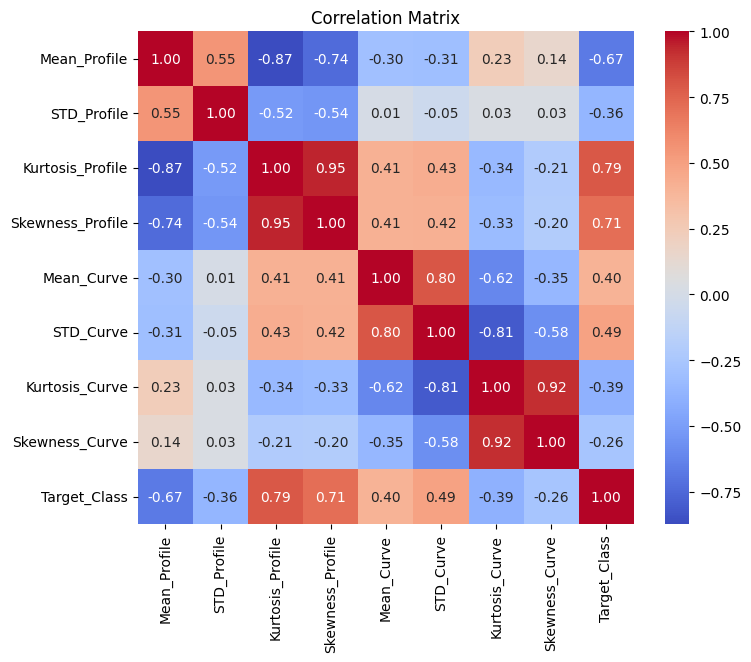

In [28]:
# Loading the dataset
col_names = [
    'Mean_Profile', 'STD_Profile', 'Kurtosis_Profile', 'Skewness_Profile',
    'Mean_Curve', 'STD_Curve', 'Kurtosis_Curve', 'Skewness_Curve',
    'Target_Class'
]

df = pd.read_csv('./data/HTRU_2.csv', header=None, names=col_names)

pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
print(df.head())

# Quality control check
missing_values = df.isnull().sum().sum()
print(f"\nNumber of missing values: {missing_values}")

# Class imbalance check
class_counts = df['Target_Class'].value_counts()
print(f"Noise signals: {class_counts[0]}, Pulsars signals: {class_counts[1]}")
print(f"Class distribution: {class_counts[0]/len(df)*100:.2f}% Noise, {class_counts[1]/len(df)*100:.2f}% Pulsars")

# Correlation Matrix
plt.figure(figsize=(8, 6.4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Phase 1: Summary & Insights

In this initial exploratory phase, a rigorous analysis of the **HTRU_2 dataset** was performed to establish a solid foundation for the predictive model. The **quality control check** confirmed that there are exactly **zero missing values** in the dataset, allowing the analysis to proceed without any data imputation. Through the **class distribution analysis**, a significant imbalance was identified, with real **Pulsars accounting for only ~9.16%** of the total samples compared to **~90.84%** of cosmic background noise. This critical finding directs the evaluation strategy away from simple accuracy, focusing instead on **Recall** to ensure no genuine scientific discoveries are discarded.

Regarding the **feature space**, the **correlation matrix** highlighted that **`Kurtosis_Profile` (0.79)** and **`Skewness_Profile` (0.71)** are the most significant linear predictors of a genuine pulsar. Despite these strong correlations, the decision was made **not to perform any feature removal**. This choice is grounded in the nature of the **Decision Tree model**, which is inherently capable of **automated feature selection**. By retaining the full feature set, the model is provided with the maximum amount of information possible, allowing it to autonomously leverage "weaker" features to resolve edge cases and ambiguous signals that a purely peaked-feature approach might miss.

## 2. Data Pre-Processing

In [30]:
# Separating features and target variable
X = df.drop('Target_Class', axis=1)
y = df['Target_Class']

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Discretization
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')

X_train_binned = discretizer.fit_transform(X_train)
X_test_binned = discretizer.transform(X_test)

X_train = pd.DataFrame(X_train_binned, columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_binned, columns=X.columns, index=X_test.index)

print(f"Training data: {X_train.shape}")
print(f"Test data: {X_test.shape}")

Training data: (14318, 8)
Test data: (3580, 8)


### Phase 2: Summary & Insights

In this phase, the raw exploratory data was transformed into a format optimized for the Decision Tree algorithm through two critically ordered steps. 

First, a **train/test split** was performed, partitioning the dataset into an **80% Training Set** (14,318 signals) and a **20% Test Set** (3,580 signals). Crucially, the **`stratify=y`** parameter was enforced. Given the severe class imbalance (~91% noise to ~9% pulsars), stratification guarantees that this exact minority-to-majority ratio is mathematically preserved in both subsets, preventing skewed and biased evaluations. Additionally, the randomness of the split was seeded using **`random_state=42`** to ensure that all future model training and benchmarks remain perfectly deterministic and reproducible.

Following the dataset split, **discretization (binning)** was applied to the continuous radio frequency measurements using `KBinsDiscretizer`, dividing them into three balanced categorical bins: **0 (Low)**, **1 (Medium)**, and **2 (High)**. This transformation smooths out extreme outliers, prevents the algorithm from creating overly specific rules (overfitting), and aligns perfectly with the discrete logical splits of Information Theory. Most importantly, executing this step *after* the train/test split—calculating the mathematical thresholds strictly on the Training Set and only applying them to the Test Set—completely eliminates the risk of **data leakage**, ensuring that the model evaluates genuinely unseen data without artificial bias.

## 3. Model Training & Visualization

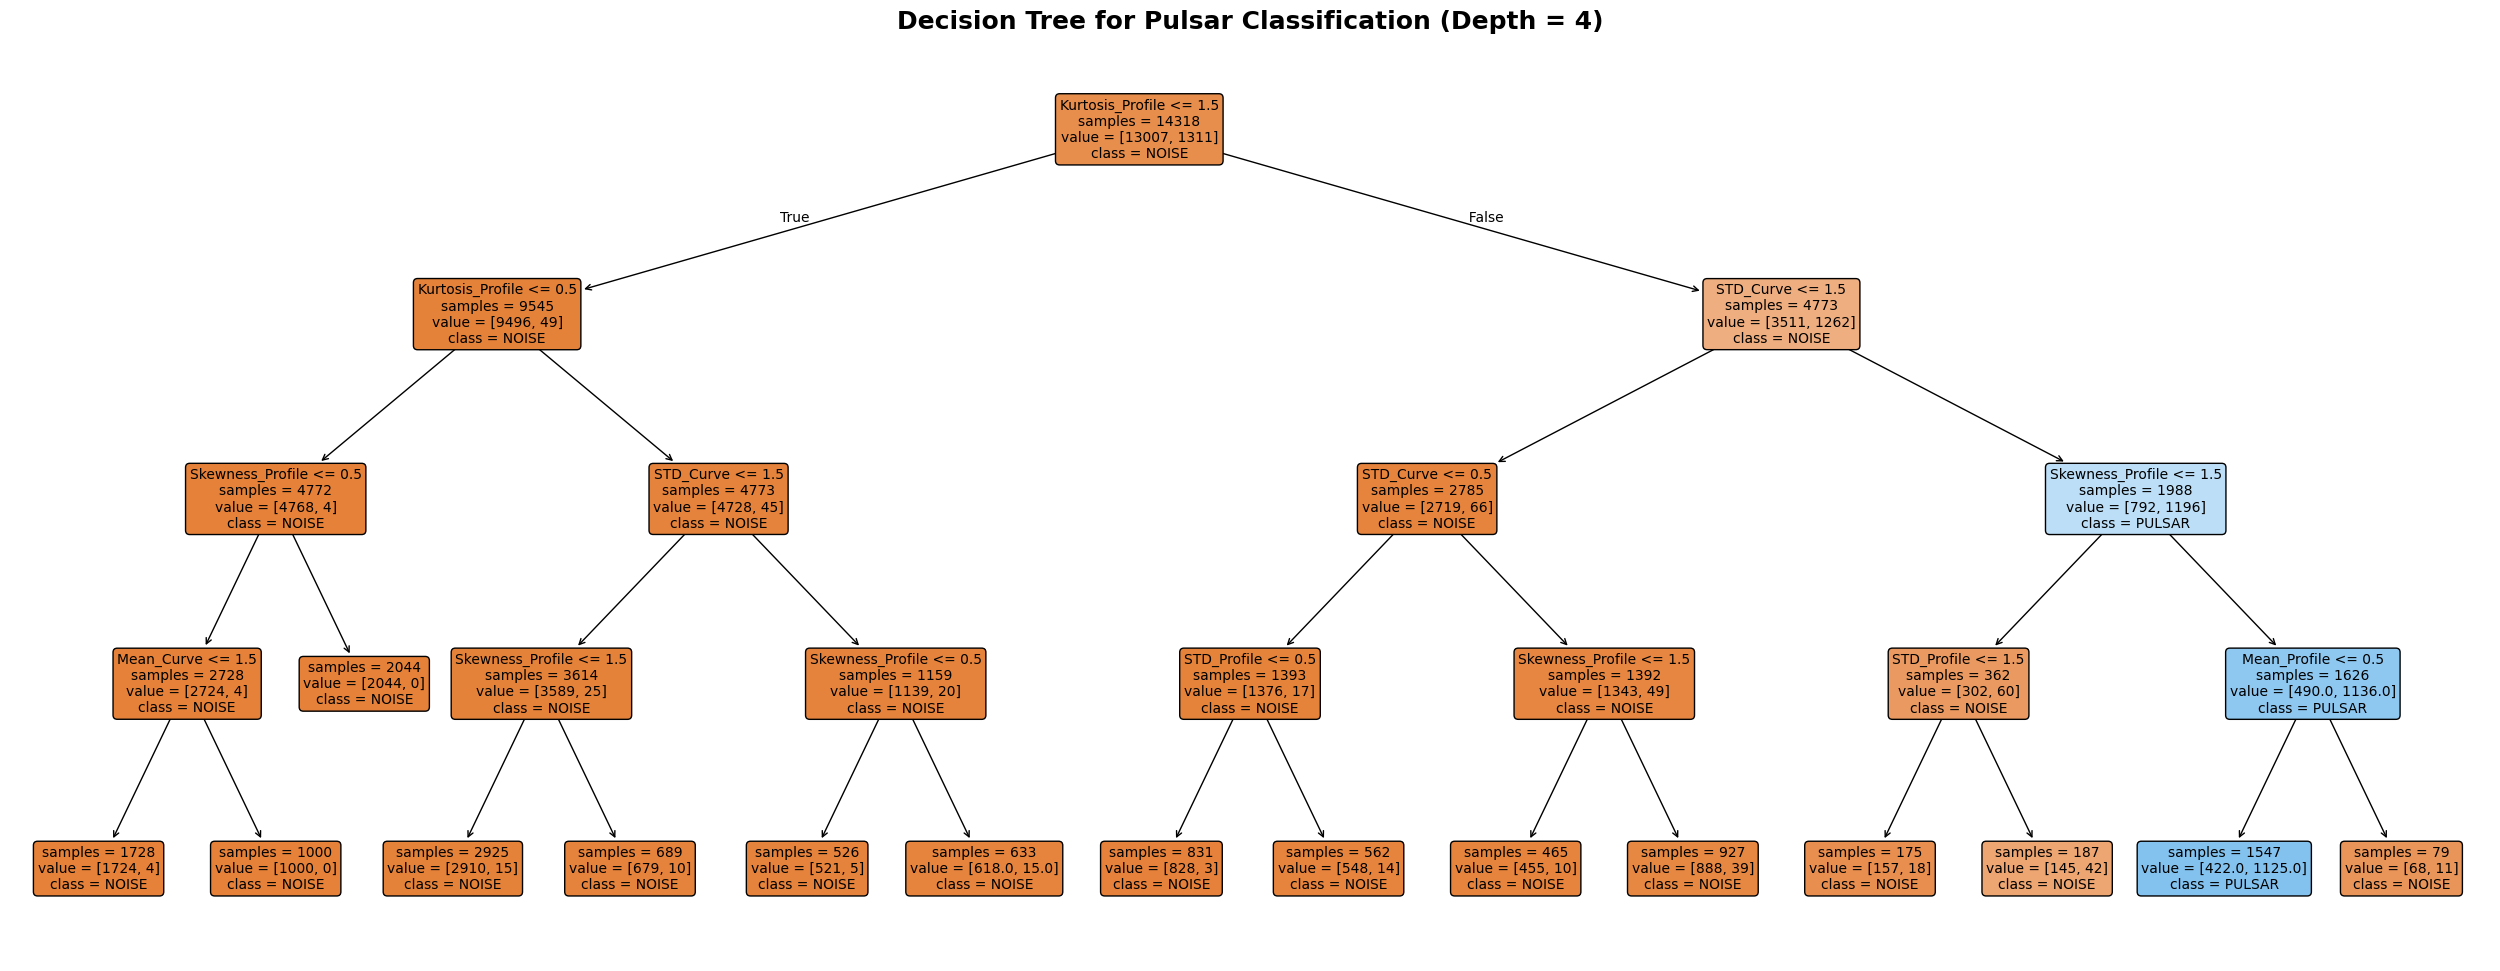

In [31]:
# Training the Decision Tree Classifier
clf = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# Visualization
plt.figure(figsize=(32, 12))
tree.plot_tree(clf, feature_names=X.columns, class_names=['NOISE', 'PULSAR'], filled=True, impurity=False, rounded=True, fontsize=10)
plt.title("Decision Tree for Pulsar Classification (Depth = 4)", fontsize=18, fontweight='bold')
plt.show()

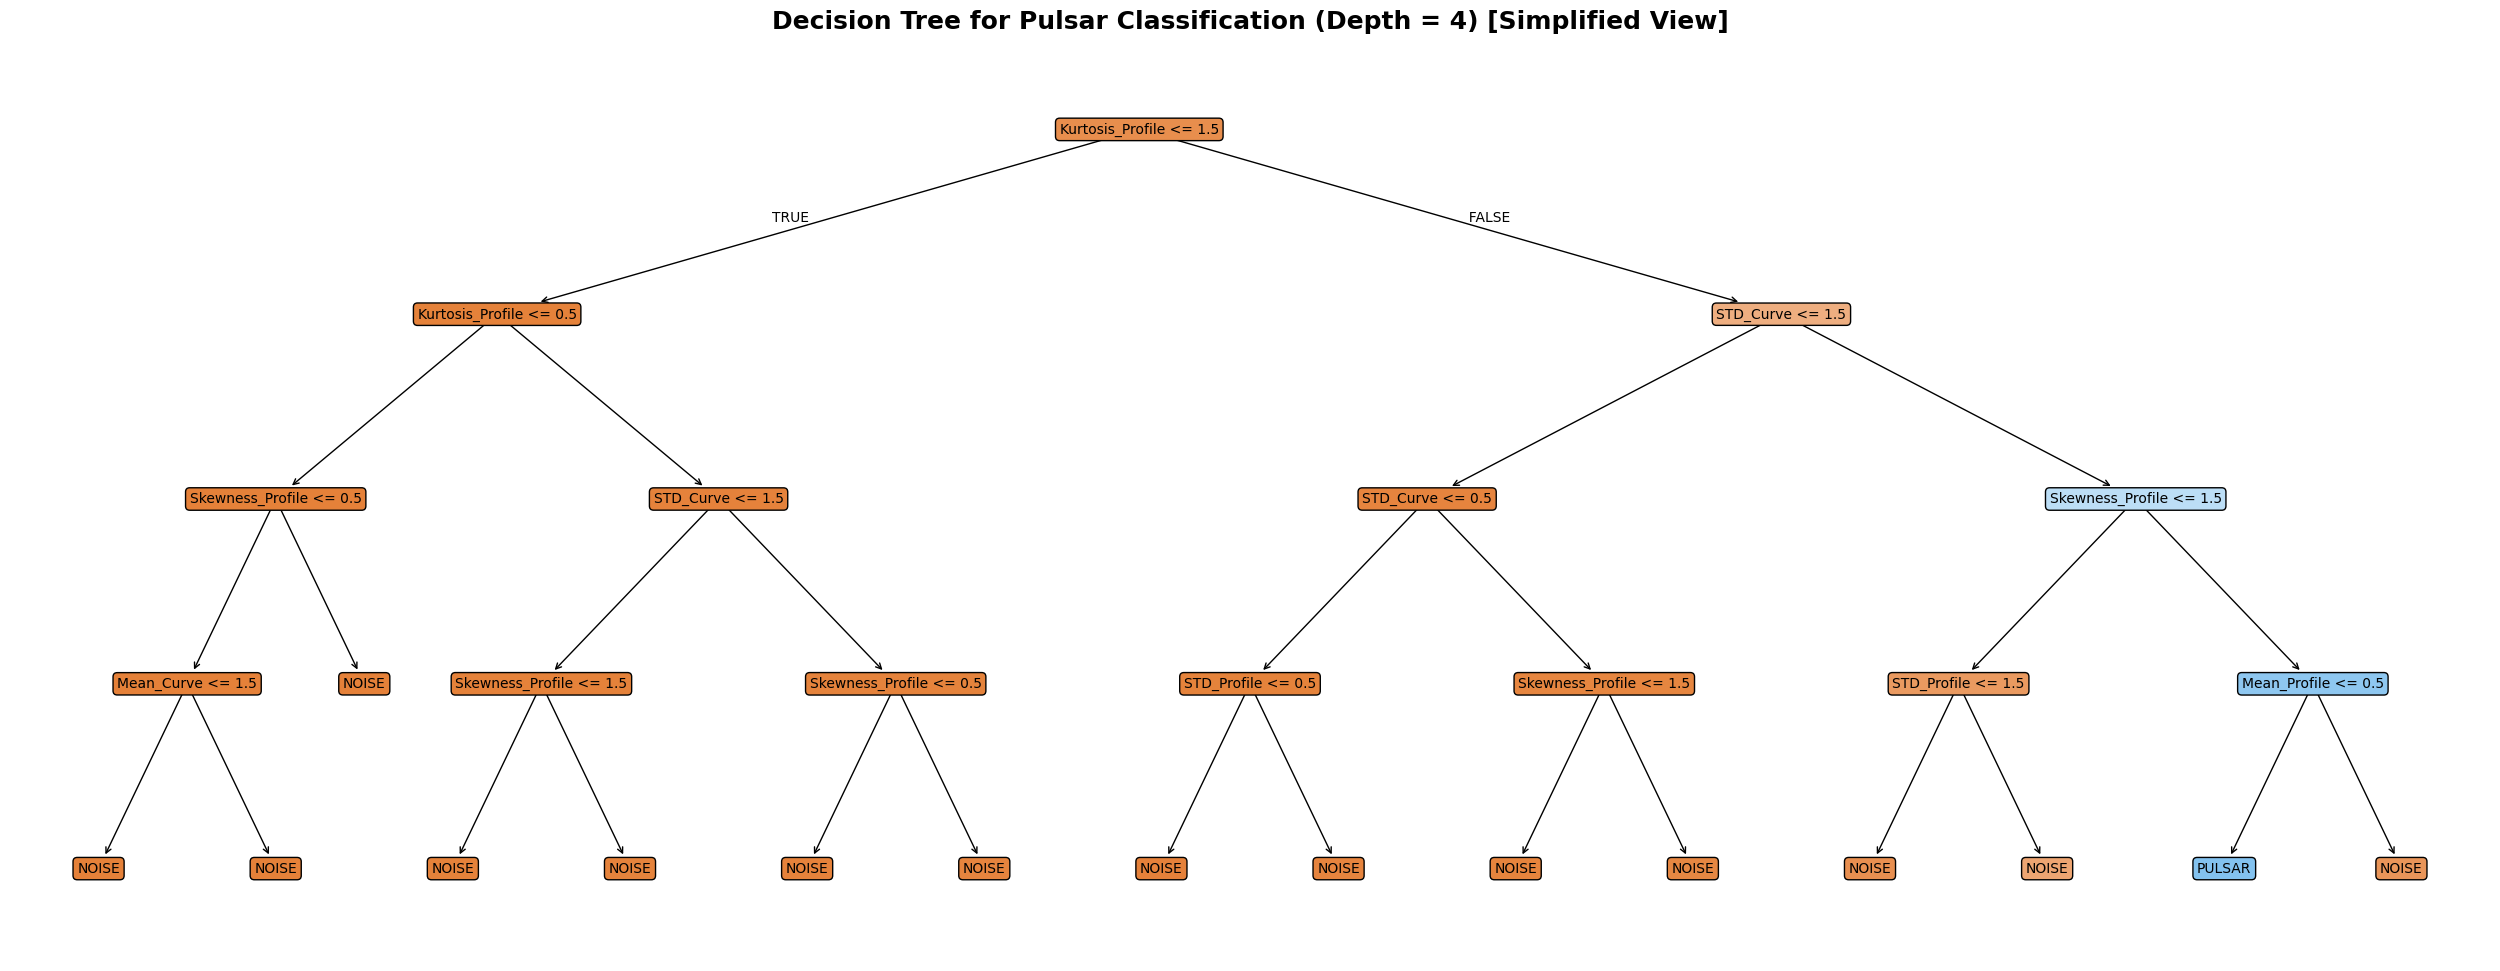

In [32]:
# Simplified Tree Visualization
plt.figure(figsize=(32, 12))
tree_plot = tree.plot_tree(clf,
                feature_names=X.columns,
                class_names=['Noise', 'Pulsar'],
                filled=True,
                rounded=True,
                fontsize=10)

for text in tree_plot:

    node_string = text.get_text()
    
    if '<=' in node_string:
        rule = node_string.split('\n')[0]
        text.set_text(rule)
    else:   # leaf node
        final_class = node_string.split('\n')[-1]
        clean_class = final_class.replace('class = ', '').upper()
        text.set_text(clean_class)

plt.title("Decision Tree for Pulsar Classification (Depth = 4) [Simplified View]", fontsize=18, fontweight='bold')
plt.show()

### Phase 3: Summary & Insights

In this phase, the predictive model was trained using a **Decision Tree Classifier**, specifically configured to operate as an efficient **Edge AI** engine. **Shannon Entropy** was utilized as the splitting criterion, which directs the algorithm to dynamically calculate the **Information Gain** at every node, ensuring that each decision split maximizes the separation between signal and noise. To guarantee the model remains lightweight and robust against overfitting, **pre-pruning** was applied by enforcing a strict **`max_depth` of 4**. This design choice prevents the tree from creating excessively complex rules, keeping the logic lean enough for direct implementation on satellite-grade microcontrollers. 

Crucially, the tree structure revealed that the model **automatically performed feature selection**, discarding 2 out of 8 input variables as non-essential for classification (**Kurtosis Curve** and **Skewness Curve**). The model identified a singular, high-precision logical path to identify a **Pulsar**: it requires **High Kurtosis Profile** (bin 2), **High Standard Deviation Curve** (bin 2), **High Skewness Profile** (bin 2), and **Low Mean Profile** (bin 0). By isolating this specific physical signature and pruning the rest, a complex statistical dataset was transformed into a streamlined, deterministic decision logic, providing a model that is both highly interpretable and physically accurate. Finally, a fixed **`random_state`** was set to ensure that the tree topology is perfectly reproducible, allowing for direct translation into a sequence of efficient, executable logic gates.

## 4. Model Evaluation

<Figure size 800x600 with 0 Axes>

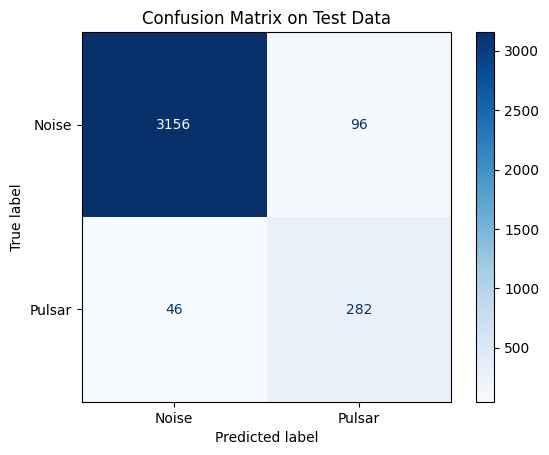

              precision    recall  f1-score   support

       Noise       0.99      0.97      0.98      3252
      Pulsar       0.75      0.86      0.80       328

    accuracy                           0.96      3580
   macro avg       0.87      0.92      0.89      3580
weighted avg       0.96      0.96      0.96      3580



In [39]:
# Prediction on the Test Set
y_pred = clf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Noise', 'Pulsar'])
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix on Test Data')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred, target_names=['Noise', 'Pulsar']))

### Phase 4: Summary & Insights

In this final phase, the predictive model was evaluated using a **Confusion Matrix** and a **Classification Report**, which together provide the ultimate proof of the system's reliability. The confusion matrix allows for the visualization of the error distribution: while the model correctly identifies the vast majority of Pulsar signals (**282 True Positives**), a minimal number of **False Negatives (46)** is also observed. These False Negatives represent the most critical trade-off in this context, as they equate to missed scientific discoveries. However, by prioritizing the **Recall score for the Pulsar class (0.86)** over global accuracy, it has been demonstrated that the Decision Tree is highly effective at capturing the minority class despite the extreme data imbalance. It is important to note that while the global **Accuracy stands at 0.96**, this metric is treated as secondary; in the context of deep-space exploration, the ability to minimize False Negatives is the true measure of success. The robust **F1-Score of 0.80** achieved for Pulsars validates that the model successfully balances precision and sensitivity, proving it is a reliable and interpretable logic engine ready for real-world deployment on satellite hardware.

## Model Benchmarking & Performance Validation

In [37]:
# 1. Baseline Model (always predicts "Class 0 / Noise")
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)
dummy_pred = dummy_clf.predict(X_test)

# 2. Advanced Model (Random Forest)
rf_clf = RandomForestClassifier(random_state=42, max_depth=4)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)

# 3. This Model (Decision Tree)
benchmark_results = {
    'Model': ['Dummy (Baseline)', 'Decision Tree (This)', 'Random Forest (Advanced)'],
    'Accuracy': [
        accuracy_score(y_test, dummy_pred),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Pulsar Recall': [
        recall_score(y_test, dummy_pred, pos_label=1),
        recall_score(y_test, y_pred, pos_label=1),
        recall_score(y_test, rf_pred, pos_label=1)
    ]
}

# Visualization of Benchmark Results
benchmark_df = pd.DataFrame(benchmark_results)
print(benchmark_df.to_string(index=False))

                   Model  Accuracy  Pulsar Recall
        Dummy (Baseline)  0.908380       0.000000
    Decision Tree (This)  0.960335       0.859756
Random Forest (Advanced)  0.963128       0.844512


### Conclusion

In this final phase, the custom Decision Tree was benchmarked against a **Dummy Classifier (Baseline)** and a **Random Forest (State-of-the-Art)** to validate the model’s performance. The Dummy Classifier confirmed that global accuracy is a misleading metric due to class imbalance, achieving high accuracy while failing to detect any Pulsars. Conversely, the custom Decision Tree achieved a remarkable **Pulsar Recall of ~0.86**, even slightly outperforming the complex Random Forest (~0.84). This unexpected result demonstrates that the tree’s "aggressive" logic, rooted in the most informative features like *Kurtosis*, is more sensitive to the Pulsar signature than the Random Forest's conservative majority-voting mechanism. 

This comparative analysis successfully concludes the pipeline, proving that a single, highly interpretable **Decision Tree** is the optimal choice for these specific requirements. By balancing computational efficiency with high sensitivity, it has been demonstrated that the model is not only physically interpretable but also robust enough for real-world deployment on satellite hardware, fulfilling the core objective of developing an effective **Edge AI** solution for deep-space signal filtering.

## Model Exportation & Example of Use

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier
import joblib

col_names = [
    'Mean_Profile', 'STD_Profile', 'Kurtosis_Profile', 'Skewness_Profile',
    'Mean_Curve', 'STD_Curve', 'Kurtosis_Curve', 'Skewness_Curve',
    'Target_Class'
]

df = pd.read_csv('./data/HTRU_2.csv', header=None, names=col_names)

X = df.drop('Target_Class', axis=1)
y = df['Target_Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pulsar_pipeline = Pipeline([
    ('binning', KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')),
    ('classifier', DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42))
])

pulsar_pipeline.fit(X_train, y_train)

joblib.dump(pulsar_pipeline, 'pulsar_classification_pipeline.joblib')

print("Production pipeline trained and exported successfully in 'pulsar_classification_pipeline.joblib'")

# Accessing the bin edges from the trained pipeline
discretizer = pulsar_pipeline.named_steps['binning']

for i, col in enumerate(X.columns):
    bordi = discretizer.bin_edges_[i]
    print(f"{col}: Edge 1 = {bordi[1]:.4f}, Edge 2 = {bordi[2]:.4f}")

Production pipeline trained and exported successfully in 'pulsar_classification_pipeline.joblib'
Mean_Profile: Edge 1 = 106.4844, Edge 2 = 123.0312
STD_Profile: Edge 1 = 44.1252, Edge 2 = 49.6345
Kurtosis_Profile: Edge 1 = 0.0932, Edge 2 = 0.3729
Skewness_Profile: Edge 1 = -0.0689, Edge 2 = 0.5760
Mean_Curve: Edge 1 = 2.1915, Edge 2 = 3.9381
STD_Curve: Edge 1 = 15.5557, Edge 2 = 23.3080
Kurtosis_Curve: Edge 1 = 6.9014, Edge 2 = 9.8322
Skewness_Curve: Edge 1 = 52.5632, Edge 2 = 116.9647


In [49]:
import joblib
import pandas as pd

pulsar_detector = joblib.load('pulsar_classification_pipeline.joblib')

col_names = [
    'Mean_Profile', 'STD_Profile', 'Kurtosis_Profile', 'Skewness_Profile',
    'Mean_Curve', 'STD_Curve', 'Kurtosis_Curve', 'Skewness_Curve'
]

raw_signal = pd.DataFrame([[25.5, 45.1, 5.2, 8.1, 2.3, 85.5, 6.7, 75.2]], columns=col_names)

classification = pulsar_detector.predict(raw_signal)

if classification[0] == 1:
    print("Pulsar detected! Sending data to Earth for further analysis.")
else:
    print("Cosmic background noise or interference. Data discarded.")

Pulsar detected! Sending data to Earth for further analysis.
